# Assignment 12: Simulating Data Parallelism and ZeRO with 32 Virtual GPUs

This notebook creates **32 simultaneous CPU worker threads** as virtual GPU ranks and trains a three-layer neural network for multiple Adam steps. It compares ordinary data parallelism with ZeRO stages 1, 2, and 3.

The deeper model makes the ZeRO-3 behavior visible. Its parameter shards are gathered **one layer at a time** during forward and backward, then released before the next layer. The experiment demonstrates that sharding changes ownership, memory, optimizer work, and communication without changing the intended optimization result.

The controller emulates collectives, while each virtual rank owns real NumPy state arrays and performs model or optimizer work on a worker thread. This is a conceptual distributed-training simulator, not a GPU speed benchmark.

## 1. Model architecture and memory assumptions

The demo is a three-layer multilayer perceptron:

```text
16 inputs → Linear 16×32 → ReLU
          → Linear 32×32 → ReLU
          → Linear 32×16 → 16 outputs
```

The three weight matrices contain `512 + 1,024 + 512 = 2,048` parameters. Biases are omitted so every layer divides evenly across 32 ranks and the ownership pattern remains easy to inspect.

For mixed-precision Adam, each parameter is represented by:

| State | Format | Bytes |
|---|---:|---:|
| Compute parameter | FP16 | 2 |
| Gradient | FP16 | 2 |
| FP32 master parameter | FP32 | 4 |
| Adam first moment | FP32 | 4 |
| Adam second moment | FP32 | 4 |
| **Total before sharding** |  | **16** |

With world size `N`, persistent bytes per parameter per rank are `16` for data parallelism, `4 + 12/N` for ZeRO-1, `2 + 14/N` for ZeRO-2, and `16/N` for ZeRO-3.

In [1]:
from concurrent.futures import ThreadPoolExecutor
from dataclasses import dataclass
import threading
import time
import numpy as np

WORLD_SIZE = 32
INPUT_DIM = 16
HIDDEN_1 = 32
HIDDEN_2 = 32
OUTPUT_DIM = 16
SAMPLES_PER_RANK = 8
TRAIN_STEPS = 4
LEARNING_RATE = 3e-3
SEED = 12

LAYER_SPECS = [
    ("W1", (INPUT_DIM, HIDDEN_1)),
    ("W2", (HIDDEN_1, HIDDEN_2)),
    ("W3", (HIDDEN_2, OUTPUT_DIM)),
]
LAYER_SIZES = [int(np.prod(shape)) for _, shape in LAYER_SPECS]
PARAM_COUNT = sum(LAYER_SIZES)
assert PARAM_COUNT == 2048
assert all(size % WORLD_SIZE == 0 for size in LAYER_SIZES)

LAYER_GLOBAL_SLICES = []
offset = 0
for size in LAYER_SIZES:
    LAYER_GLOBAL_SLICES.append(slice(offset, offset + size))
    offset += size

LAYER_SHARD_SIZES = [size // WORLD_SIZE for size in LAYER_SIZES]
LOCAL_LAYER_SLICES = []
local_offset = 0
for shard_size in LAYER_SHARD_SIZES:
    LOCAL_LAYER_SLICES.append(slice(local_offset, local_offset + shard_size))
    local_offset += shard_size
SHARD_SIZE = local_offset

OWNED_INDICES = []
for rank in range(WORLD_SIZE):
    owned = []
    for global_slice, shard_size in zip(LAYER_GLOBAL_SLICES, LAYER_SHARD_SIZES):
        start = global_slice.start + rank * shard_size
        owned.extend(range(start, start + shard_size))
    OWNED_INDICES.append(np.asarray(owned, dtype=np.int64))

np.set_printoptions(precision=6, suppress=True)

print(f"World size: {WORLD_SIZE} virtual ranks")
print(f"NumPy version: {np.__version__}")
print(f"Model parameters: {PARAM_COUNT:,} ({SHARD_SIZE} owned per rank)")
print(f"Global batch per step: {WORLD_SIZE * SAMPLES_PER_RANK} samples")
print(f"Training steps: {TRAIN_STEPS}")
print()
for (name, shape), size, shard_size in zip(LAYER_SPECS, LAYER_SIZES, LAYER_SHARD_SIZES):
    print(f"{name}: shape={shape}, parameters={size:,}, shard/rank={shard_size}")

World size: 32 virtual ranks
NumPy version: 2.3.5
Model parameters: 2,048 (64 owned per rank)
Global batch per step: 256 samples
Training steps: 4

W1: shape=(16, 32), parameters=512, shard/rank=16
W2: shape=(32, 32), parameters=1,024, shard/rank=32
W3: shape=(32, 16), parameters=512, shard/rank=16


## 2. Synthetic nonlinear regression data

A fixed three-layer teacher network generates targets from random inputs. The student network has the same architecture but different initial parameters. ReLU activations make this a genuine nonlinear neural network rather than linear regression.

Every rank receives a different microbatch. All four distributed strategies start from identical parameters and consume the same batches in the same order.

In [2]:
rng = np.random.default_rng(SEED)


def initialize_layer(shape, generator):
    fan_in = shape[0]
    return generator.normal(0, np.sqrt(2.0 / fan_in), size=shape).astype(np.float32)


def initialize_model(generator):
    return np.concatenate([initialize_layer(shape, generator).ravel() for _, shape in LAYER_SPECS])


def unpack_model(flat_parameters):
    matrices = []
    for (_, shape), global_slice in zip(LAYER_SPECS, LAYER_GLOBAL_SLICES):
        matrices.append(flat_parameters[global_slice].reshape(shape).astype(np.float32))
    return matrices


def network_forward(flat_parameters, x):
    w1, w2, w3 = unpack_model(flat_parameters)
    h1 = np.maximum(x @ w1, 0.0)
    h2 = np.maximum(h1 @ w2, 0.0)
    return h2 @ w3


teacher_parameters = initialize_model(rng)
initial_master = initialize_model(rng)


def make_batches(generator):
    batches = []
    for _ in range(WORLD_SIZE):
        x = generator.normal(size=(SAMPLES_PER_RANK, INPUT_DIM)).astype(np.float32)
        noise = generator.normal(0, 0.01, size=(SAMPLES_PER_RANK, OUTPUT_DIM)).astype(np.float32)
        y = network_forward(teacher_parameters, x) + noise
        batches.append((x, y.astype(np.float32)))
    return batches


training_batches = [make_batches(rng) for _ in range(TRAIN_STEPS)]
evaluation_batches = make_batches(rng)


def mse_loss(parameters_fp16, batches):
    squared_error = 0.0
    elements = 0
    for x, y in batches:
        error = network_forward(parameters_fp16, x) - y
        squared_error += float(np.sum(error * error))
        elements += error.size
    return squared_error / elements


print(f"Initial evaluation loss: {mse_loss(initial_master.astype(np.float16), evaluation_batches):.6f}")

Initial evaluation loss: 5.572334


## 3. Per-rank persistent state

Every virtual rank owns actual arrays matching the selected strategy:

- **Data parallel:** complete parameters, gradients, FP32 master parameters, and Adam states.
- **ZeRO-1:** complete parameters and a full-sized local gradient buffer during backward, but only one optimizer shard. After reduce-scatter, only the owned averaged gradient shard is needed for the update.
- **ZeRO-2:** complete parameters, one gradient shard, and one optimizer shard.
- **ZeRO-3:** one shard of every layer's parameters, gradients, and optimizer state.

The toy memory table is measured directly from `array.nbytes`. Here, “full gradient” describes the full-sized buffer allocated during backward; it does not mean that every rank retains a full synchronized averaged gradient after reduce-scatter.

### Ownership summary

The diagram below shows the single rule that changes from one stage to the next: **full** means every rank stores a complete copy, while **sharded** means the 32 ranks divide ownership so each rank stores only its assigned piece.

Strategy        Parameters   Gradients    Optimizer   
-------------------------------------------------------
Data Parallel   Full         Full         Full        
ZeRO-1          Full         Full         Sharded     
ZeRO-2          Full         Sharded      Sharded     
ZeRO-3          Sharded      Sharded      Sharded     


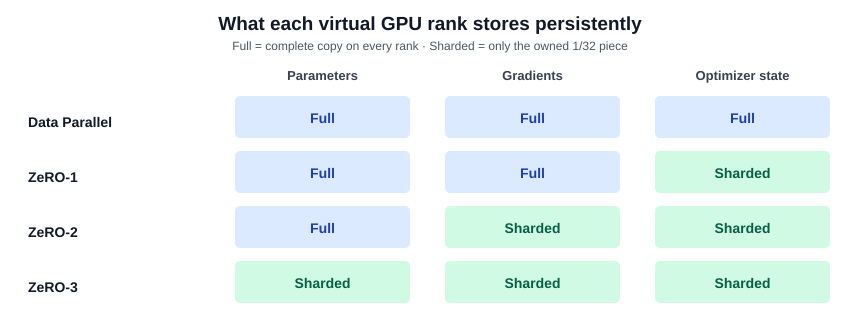

In [3]:
# OWNERSHIP_DIAGRAM
ownership_rows = [
    ("Data Parallel", "Full", "Full", "Full"),
    ("ZeRO-1", "Full", "Full", "Sharded"),
    ("ZeRO-2", "Full", "Sharded", "Sharded"),
    ("ZeRO-3", "Sharded", "Sharded", "Sharded"),
]


def build_ownership_svg(rows):
    width, height = 860, 330
    label_x = 28
    column_x = [235, 445, 655]
    column_width = 175
    headers = ["Parameters", "Gradients", "Optimizer state"]
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        '<text x="430" y="30" text-anchor="middle" font-family="Arial" font-size="19" font-weight="bold" fill="#111827">What each virtual GPU rank stores persistently</text>',
        '<text x="430" y="50" text-anchor="middle" font-family="Arial" font-size="12" fill="#4B5563">Full = complete copy on every rank · Sharded = only the owned 1/32 piece</text>',
    ]
    for x, header in zip(column_x, headers):
        parts.append(f'<text x="{x + column_width / 2:.1f}" y="80" text-anchor="middle" font-family="Arial" font-size="13" font-weight="bold" fill="#374151">{header}</text>')
    for row_index, row in enumerate(rows):
        y = 96 + row_index * 55
        strategy, *states = row
        parts.append(f'<text x="{label_x}" y="{y + 31}" font-family="Arial" font-size="14" font-weight="bold" fill="#111827">{strategy}</text>')
        for x, state in zip(column_x, states):
            fill = "#DBEAFE" if state == "Full" else "#D1FAE5"
            text_fill = "#1E40AF" if state == "Full" else "#065F46"
            parts.append(f'<rect x="{x}" y="{y}" width="{column_width}" height="42" rx="5" fill="{fill}"/>')
            parts.append(f'<text x="{x + column_width / 2:.1f}" y="{y + 27}" text-anchor="middle" font-family="Arial" font-size="14" font-weight="bold" fill="{text_fill}">{state}</text>')
    parts.append('</svg>')
    return ''.join(parts)


OWNERSHIP_DIAGRAM_SVG = build_ownership_svg(ownership_rows)
try:
    from IPython.display import SVG, display
    display(SVG(OWNERSHIP_DIAGRAM_SVG))
except ImportError:
    print(f"{'Strategy':<15} {'Parameters':<12} {'Gradients':<12} {'Optimizer':<12}")
    print('-' * 55)
    for strategy, parameters, gradients, optimizer in ownership_rows:
        print(f"{strategy:<15} {parameters:<12} {gradients:<12} {optimizer:<12}")

In [4]:
@dataclass
class RankState:
    rank: int
    parameters: np.ndarray
    gradients: np.ndarray
    master: np.ndarray
    adam_m: np.ndarray
    adam_v: np.ndarray

    def component_bytes(self):
        return {
            "parameters": self.parameters.nbytes,
            "gradients": self.gradients.nbytes,
            "optimizer": self.master.nbytes + self.adam_m.nbytes + self.adam_v.nbytes,
        }

    def persistent_bytes(self):
        return sum(self.component_bytes().values())


def create_states(strategy):
    states = []
    for rank in range(WORLD_SIZE):
        owned = OWNED_INDICES[rank]
        if strategy == "Data Parallel":
            parameters = initial_master.astype(np.float16).copy()
            gradients = np.zeros(PARAM_COUNT, dtype=np.float16)
            master = initial_master.copy()
        elif strategy == "ZeRO-1":
            parameters = initial_master.astype(np.float16).copy()
            gradients = np.zeros(PARAM_COUNT, dtype=np.float16)
            master = initial_master[owned].copy()
        elif strategy == "ZeRO-2":
            parameters = initial_master.astype(np.float16).copy()
            gradients = np.zeros(SHARD_SIZE, dtype=np.float16)
            master = initial_master[owned].copy()
        elif strategy == "ZeRO-3":
            parameters = initial_master[owned].astype(np.float16).copy()
            gradients = np.zeros(SHARD_SIZE, dtype=np.float16)
            master = initial_master[owned].copy()
        else:
            raise ValueError(strategy)
        states.append(
            RankState(
                rank=rank,
                parameters=parameters,
                gradients=gradients,
                master=master,
                adam_m=np.zeros_like(master),
                adam_v=np.zeros_like(master),
            )
        )
    return states


STRATEGIES = ["Data Parallel", "ZeRO-1", "ZeRO-2", "ZeRO-3"]
initial_states = {strategy: create_states(strategy) for strategy in STRATEGIES}

print(f"{'Strategy':<15} {'Param bytes':>13} {'Grad bytes':>12} {'Optimizer bytes':>16} {'Total/rank':>13}")
print('-' * 73)
for strategy in STRATEGIES:
    parts = initial_states[strategy][0].component_bytes()
    print(
        f"{strategy:<15} {parts['parameters']:>13,} {parts['gradients']:>12,} "
        f"{parts['optimizer']:>16,} {sum(parts.values()):>13,}"
    )

Strategy          Param bytes   Grad bytes  Optimizer bytes    Total/rank
-------------------------------------------------------------------------
Data Parallel           4,096        4,096           24,576        32,768
ZeRO-1                  4,096        4,096              768         8,960
ZeRO-2                  4,096          128              768         4,992
ZeRO-3                    128          128              768         1,024


### Example layer-shard ownership

Each layer is independently split across all 32 ranks. A rank therefore owns a small consecutive range from `W1`, `W2`, and `W3`. The table uses flattened global parameter indices with an exclusive stop index.

In [5]:
example_ranks = [0, 1, 15, 30, 31]
print(f"{'Rank':>4} {'W1 global range':>17} {'W2 global range':>17} {'W3 global range':>17} {'Total':>7}")
print('-' * 69)
for rank in example_ranks:
    ranges = []
    for global_slice, shard_size in zip(LAYER_GLOBAL_SLICES, LAYER_SHARD_SIZES):
        start = global_slice.start + rank * shard_size
        ranges.append(f"[{start}:{start + shard_size})")
    print(f"{rank:>4} {ranges[0]:>17} {ranges[1]:>17} {ranges[2]:>17} {SHARD_SIZE:>7}")

covered = np.sort(np.concatenate(OWNED_INDICES))
np.testing.assert_array_equal(covered, np.arange(PARAM_COUNT))
print()
print("PASS: all layer shards cover every parameter exactly once with no gaps or overlap.")

Rank   W1 global range   W2 global range   W3 global range   Total
---------------------------------------------------------------------
   0            [0:16)         [512:544)       [1536:1552)      64
   1           [16:32)         [544:576)       [1552:1568)      64
  15         [240:256)        [992:1024)       [1776:1792)      64
  30         [480:496)       [1472:1504)       [2016:2032)      64
  31         [496:512)       [1504:1536)       [2032:2048)      64

PASS: all layer shards cover every parameter exactly once with no gaps or overlap.


## 4. Worker execution, neural-network passes, and collectives

For data parallelism, ZeRO-1, and ZeRO-2, every rank persistently holds all three FP16 weight matrices and can run a complete forward/backward pass locally.

For ZeRO-3, the simulator gathers only the current layer:

```text
Forward:  gather W1 → compute → release W1
          gather W2 → compute → release W2
          gather W3 → compute → release W3

Backward: gather W3 → compute gradients → release W3
          gather W2 → compute gradients → release W2
          gather W1 → compute gradients → release W1
```

This shows why ZeRO-3 has low persistent memory but more communication and layer orchestration.

In [6]:
def reconstruct_from_owned_shards(shards):
    full = np.empty(PARAM_COUNT, dtype=shards[0].dtype)
    for rank, shard in enumerate(shards):
        full[OWNED_INDICES[rank]] = shard
    return full


def gather_zero3_layer(states, layer_index):
    local_slice = LOCAL_LAYER_SLICES[layer_index]
    return np.concatenate([state.parameters[local_slice] for state in states])


def reduce_scatter_mean(full_gradients):
    averaged = np.mean(np.stack(full_gradients, axis=0), axis=0, dtype=np.float32)
    return [averaged[OWNED_INDICES[rank]].copy() for rank in range(WORLD_SIZE)]


def all_reduce_mean(full_gradients):
    return np.mean(np.stack(full_gradients, axis=0), axis=0, dtype=np.float32)


def ring_all_gather_bytes(payload_bytes):
    return (WORLD_SIZE - 1) / WORLD_SIZE * payload_bytes


def ring_reduce_scatter_bytes(payload_bytes):
    return (WORLD_SIZE - 1) / WORLD_SIZE * payload_bytes


def ring_all_reduce_bytes(payload_bytes):
    return 2 * (WORLD_SIZE - 1) / WORLD_SIZE * payload_bytes


def parallel_map_32(function, items):
    barrier = threading.Barrier(WORLD_SIZE)

    def wrapped(item):
        barrier.wait()
        value = function(item)
        return threading.get_ident(), value

    with ThreadPoolExecutor(max_workers=WORLD_SIZE, thread_name_prefix="virtual-gpu") as pool:
        results = list(pool.map(wrapped, items))
    thread_count = len({thread_id for thread_id, _ in results})
    assert thread_count == WORLD_SIZE
    return [value for _, value in results], thread_count


def forward_full_worker(item):
    parameters_fp16, batch = item
    x, y = batch
    w1, w2, w3 = unpack_model(parameters_fp16)
    z1 = x @ w1
    h1 = np.maximum(z1, 0.0)
    z2 = h1 @ w2
    h2 = np.maximum(z2, 0.0)
    prediction = h2 @ w3
    return {"x": x, "y": y, "z1": z1, "h1": h1, "z2": z2, "h2": h2, "prediction": prediction}


def backward_full_worker(item):
    parameters_fp16, cache = item
    w1, w2, w3 = unpack_model(parameters_fp16)
    scale = 2.0 / cache["prediction"].size
    d_prediction = scale * (cache["prediction"] - cache["y"])
    d_w3 = cache["h2"].T @ d_prediction
    d_h2 = d_prediction @ w3.T
    d_z2 = d_h2 * (cache["z2"] > 0)
    d_w2 = cache["h1"].T @ d_z2
    d_h1 = d_z2 @ w2.T
    d_z1 = d_h1 * (cache["z1"] > 0)
    d_w1 = cache["x"].T @ d_z1
    _d_input = d_z1 @ w1.T
    return np.concatenate([d_w1.ravel(), d_w2.ravel(), d_w3.ravel()]).astype(np.float16)


def z3_forward_w1(item):
    batch, w1 = item
    x, y = batch
    z1 = x @ w1
    return {"x": x, "y": y, "z1": z1, "h1": np.maximum(z1, 0.0)}


def z3_forward_w2(item):
    cache, w2 = item
    z2 = cache["h1"] @ w2
    cache = dict(cache)
    cache.update({"z2": z2, "h2": np.maximum(z2, 0.0)})
    return cache


def z3_forward_w3(item):
    cache, w3 = item
    cache = dict(cache)
    cache["prediction"] = cache["h2"] @ w3
    return cache


def z3_backward_w3(item):
    cache, w3 = item
    scale = 2.0 / cache["prediction"].size
    d_prediction = scale * (cache["prediction"] - cache["y"])
    result = dict(cache)
    result["d_w3"] = cache["h2"].T @ d_prediction
    result["d_h2"] = d_prediction @ w3.T
    return result


def z3_backward_w2(item):
    cache, w2 = item
    d_z2 = cache["d_h2"] * (cache["z2"] > 0)
    result = dict(cache)
    result["d_w2"] = cache["h1"].T @ d_z2
    result["d_h1"] = d_z2 @ w2.T
    return result


def z3_backward_w1(item):
    cache, w1 = item
    d_z1 = cache["d_h1"] * (cache["z1"] > 0)
    d_w1 = cache["x"].T @ d_z1
    _d_input = d_z1 @ w1.T
    return np.concatenate([d_w1.ravel(), cache["d_w2"].ravel(), cache["d_w3"].ravel()]).astype(np.float16)


def adam_update(master, m, v, gradient, step, lr=LEARNING_RATE,
                beta1=0.9, beta2=0.999, eps=1e-8):
    m = beta1 * m + (1.0 - beta1) * gradient
    v = beta2 * v + (1.0 - beta2) * (gradient * gradient)
    m_hat = m / (1.0 - beta1 ** step)
    v_hat = v / (1.0 - beta2 ** step)
    master = master - lr * m_hat / (np.sqrt(v_hat) + eps)
    return master.astype(np.float32), m.astype(np.float32), v.astype(np.float32)


def update_worker(item):
    state, gradient, step = item
    return adam_update(state.master, state.adam_m, state.adam_v, gradient, step)


print("Three-layer forward/backward and collective helpers are ready.")

Three-layer forward/backward and collective helpers are ready.


## 5. Multi-step distributed simulation

The optimizer state is carried across four updates. Data parallelism performs a full optimizer update on every rank. Each ZeRO strategy performs only the owned shard update.

ZeRO-1 and ZeRO-2 use gradient reduce-scatter plus updated-parameter all-gather. ZeRO-3 uses six layer all-gathers per step—three during forward and three during backward—plus gradient reduce-scatter.

In [7]:
@dataclass
class RunResult:
    strategy: str
    states: list
    full_master: np.ndarray
    full_m: np.ndarray
    full_v: np.ndarray
    full_parameters_fp16: np.ndarray
    loss_history: list
    loss_after: float
    communication_bytes_per_rank: float
    persistent_bytes_per_rank: int
    transient_peak_parameter_bytes: int
    transient_peak_gradient_bytes: int
    elapsed_seconds: float
    worker_threads: int


def reconstruct(states, field):
    first = getattr(states[0], field)
    if first.size == PARAM_COUNT:
        return first.copy()
    return reconstruct_from_owned_shards([getattr(state, field) for state in states])


def run_zero3_forward(states, batches, communication):
    transient_peak = 0
    threads_seen = 0
    layer_functions = [z3_forward_w1, z3_forward_w2, z3_forward_w3]
    caches = batches
    for layer_index, (function, (_, shape), layer_size) in enumerate(zip(layer_functions, LAYER_SPECS, LAYER_SIZES)):
        layer_vector = gather_zero3_layer(states, layer_index)
        layer_matrix = layer_vector.reshape(shape).astype(np.float32)
        communication["parameter_all_gather"] += ring_all_gather_bytes(layer_vector.nbytes)
        transient_peak = max(transient_peak, layer_vector.nbytes)
        inputs = list(zip(caches, [layer_matrix] * WORLD_SIZE))
        caches, threads = parallel_map_32(function, inputs)
        threads_seen = max(threads_seen, threads)
        del layer_vector, layer_matrix
    return caches, transient_peak, threads_seen


def run_zero3_backward(states, caches, communication):
    threads_seen = 0
    backward_order = [2, 1, 0]
    functions = [z3_backward_w3, z3_backward_w2, z3_backward_w1]
    for layer_index, function in zip(backward_order, functions):
        _, shape = LAYER_SPECS[layer_index]
        layer_vector = gather_zero3_layer(states, layer_index)
        layer_matrix = layer_vector.reshape(shape).astype(np.float32)
        communication["parameter_all_gather"] += ring_all_gather_bytes(layer_vector.nbytes)
        inputs = list(zip(caches, [layer_matrix] * WORLD_SIZE))
        caches, threads = parallel_map_32(function, inputs)
        threads_seen = max(threads_seen, threads)
        del layer_vector, layer_matrix
    return caches, threads_seen


def run_strategy(strategy):
    states = create_states(strategy)
    full_payload_bytes = PARAM_COUNT * np.dtype(np.float16).itemsize
    communication = {"all_reduce": 0.0, "reduce_scatter": 0.0, "parameter_all_gather": 0.0}
    transient_parameter_peak = 0
    worker_threads = 0
    loss_history = [mse_loss(initial_master.astype(np.float16), evaluation_batches)]
    started = time.perf_counter()

    for step_index, batches in enumerate(training_batches, start=1):
        if strategy == "ZeRO-3":
            caches, transient_peak, threads = run_zero3_forward(states, batches, communication)
            transient_parameter_peak = max(transient_parameter_peak, transient_peak)
            worker_threads = max(worker_threads, threads)
            local_gradients, threads = run_zero3_backward(states, caches, communication)
            worker_threads = max(worker_threads, threads)
        else:
            forward_inputs = [(states[rank].parameters, batches[rank]) for rank in range(WORLD_SIZE)]
            caches, threads = parallel_map_32(forward_full_worker, forward_inputs)
            worker_threads = max(worker_threads, threads)
            backward_inputs = [(states[rank].parameters, caches[rank]) for rank in range(WORLD_SIZE)]
            local_gradients, threads = parallel_map_32(backward_full_worker, backward_inputs)
            worker_threads = max(worker_threads, threads)

        if strategy == "Data Parallel":
            averaged_gradient = all_reduce_mean(local_gradients)
            communication["all_reduce"] += ring_all_reduce_bytes(full_payload_bytes)
            update_inputs = []
            for state in states:
                state.gradients = averaged_gradient.astype(np.float16)
                update_inputs.append((state, averaged_gradient, step_index))
            updates, threads = parallel_map_32(update_worker, update_inputs)
            worker_threads = max(worker_threads, threads)
            for state, (master, m, v) in zip(states, updates):
                state.master, state.adam_m, state.adam_v = master, m, v
                state.parameters = master.astype(np.float16)
        else:
            gradient_shards = reduce_scatter_mean(local_gradients)
            communication["reduce_scatter"] += ring_reduce_scatter_bytes(full_payload_bytes)
            update_inputs = []
            for rank, state in enumerate(states):
                if strategy == "ZeRO-1":
                    state.gradients = local_gradients[rank].astype(np.float16)
                else:
                    state.gradients = gradient_shards[rank].astype(np.float16)
                update_inputs.append((state, gradient_shards[rank], step_index))
            updates, threads = parallel_map_32(update_worker, update_inputs)
            worker_threads = max(worker_threads, threads)
            updated_shards = []
            for state, (master, m, v) in zip(states, updates):
                state.master, state.adam_m, state.adam_v = master, m, v
                updated_shards.append(master.astype(np.float16))

            if strategy in ("ZeRO-1", "ZeRO-2"):
                replicated_parameters = reconstruct_from_owned_shards(updated_shards)
                communication["parameter_all_gather"] += ring_all_gather_bytes(full_payload_bytes)
                for state in states:
                    state.parameters = replicated_parameters.copy()
            else:
                for state, shard in zip(states, updated_shards):
                    state.parameters = shard

        current_parameters = reconstruct(states, "parameters")
        loss_history.append(mse_loss(current_parameters, evaluation_batches))

    full_master = reconstruct(states, "master")
    full_m = reconstruct(states, "adam_m")
    full_v = reconstruct(states, "adam_v")
    full_parameters = reconstruct(states, "parameters")
    return RunResult(
        strategy=strategy,
        states=states,
        full_master=full_master,
        full_m=full_m,
        full_v=full_v,
        full_parameters_fp16=full_parameters,
        loss_history=loss_history,
        loss_after=mse_loss(full_parameters, evaluation_batches),
        communication_bytes_per_rank=sum(communication.values()),
        persistent_bytes_per_rank=states[0].persistent_bytes(),
        transient_peak_parameter_bytes=transient_parameter_peak,
        transient_peak_gradient_bytes=full_payload_bytes,
        elapsed_seconds=time.perf_counter() - started,
        worker_threads=worker_threads,
    )


results = [run_strategy(strategy) for strategy in STRATEGIES]
P_BYTES = PARAM_COUNT * np.dtype(np.float16).itemsize

print(f"{'Strategy':<15} {'Threads':>8} {'Eval loss':>12} {'Persistent':>12} {'Largest layer':>14} {'Transient G':>12} {'Comm/step':>12} {'CPU wall s':>11}")
print('-' * 105)
for result in results:
    communication_p = result.communication_bytes_per_rank / TRAIN_STEPS / P_BYTES
    print(
        f"{result.strategy:<15} {result.worker_threads:>8d} {result.loss_after:>12.6f} "
        f"{result.persistent_bytes_per_rank:>12,} {result.transient_peak_parameter_bytes:>14,} "
        f"{result.transient_peak_gradient_bytes:>12,} {communication_p:>11.4f}P "
        f"{result.elapsed_seconds:>11.4f}"
    )

print()
print("For ZeRO-3, 'Largest layer' is the peak gathered FP16 layer, not a full-model parameter copy.")
print("CPU wall time is a simulator health check, not a GPU performance comparison.")

Strategy         Threads    Eval loss   Persistent  Largest layer  Transient G    Comm/step  CPU wall s
---------------------------------------------------------------------------------------------------------
Data Parallel         32     4.105666       32,768              0        4,096      1.9375P      0.3299
ZeRO-1                32     4.105666        8,960              0        4,096      1.9375P      0.2905
ZeRO-2                32     4.105666        4,992              0        4,096      1.9375P      0.3033
ZeRO-3                32     4.105666        1,024          2,048        4,096      2.9062P      0.3332

For ZeRO-3, 'Largest layer' is the peak gathered FP16 layer, not a full-model parameter copy.
CPU wall time is a simulator health check, not a GPU performance comparison.


### Loss comparison across four updates

All four strategies begin from the same parameters and use the same microbatches. Their loss values therefore overlap when the sharding and collective logic is correct. The table keeps every strategy visible; the curve draws the shared trajectory once so identical lines do not hide one another.

Step   Data Parallel          ZeRO-1          ZeRO-2          ZeRO-3
--------------------------------------------------------------------
   0        5.572334        5.572334        5.572334        5.572334
   1        5.143653        5.143653        5.143653        5.143653
   2        4.759675        4.759675        4.759675        4.759675
   3        4.414552        4.414552        4.414552        4.414552
   4        4.105666        4.105666        4.105666        4.105666
Loss curve display is available in Jupyter and Colab.


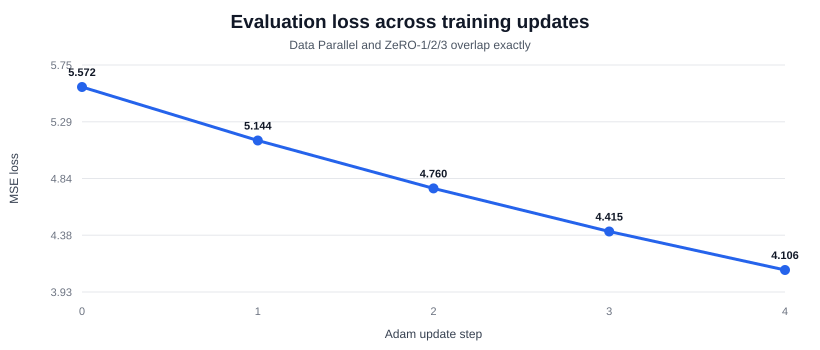

In [8]:
# LOSS_COMPARISON_CHART
loss_steps = list(range(TRAIN_STEPS + 1))
print(f"{'Step':>4}" + ''.join(f"{strategy:>16}" for strategy in STRATEGIES))
print('-' * (4 + 16 * len(STRATEGIES)))
for step in loss_steps:
    print(f"{step:>4}" + ''.join(f"{result.loss_history[step]:>16.6f}" for result in results))


def build_loss_curve_svg(steps, values):
    width, height = 820, 350
    left, right, top, bottom = 82, 785, 65, 292
    plot_width, plot_height = right - left, bottom - top
    y_min = min(values)
    y_max = max(values)
    padding = max(0.05, (y_max - y_min) * 0.12)
    domain_min, domain_max = y_min - padding, y_max + padding

    def x_position(step):
        return left + plot_width * step / max(steps)

    def y_position(value):
        return bottom - plot_height * (value - domain_min) / (domain_max - domain_min)

    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        '<text x="410" y="28" text-anchor="middle" font-family="Arial" font-size="19" font-weight="bold" fill="#111827">Evaluation loss across training updates</text>',
        '<text x="410" y="49" text-anchor="middle" font-family="Arial" font-size="12" fill="#4B5563">Data Parallel and ZeRO-1/2/3 overlap exactly</text>',
    ]
    for tick_index in range(5):
        tick_value = domain_min + (domain_max - domain_min) * tick_index / 4
        y = y_position(tick_value)
        parts.append(f'<line x1="{left}" y1="{y:.1f}" x2="{right}" y2="{y:.1f}" stroke="#E5E7EB" stroke-width="1"/>')
        parts.append(f'<text x="{left - 10}" y="{y + 4:.1f}" text-anchor="end" font-family="Arial" font-size="11" fill="#6B7280">{tick_value:.2f}</text>')
    for step in steps:
        x = x_position(step)
        parts.append(f'<text x="{x:.1f}" y="{bottom + 23}" text-anchor="middle" font-family="Arial" font-size="11" fill="#6B7280">{step}</text>')
    points = ' '.join(f'{x_position(step):.1f},{y_position(value):.1f}' for step, value in zip(steps, values))
    parts.append(f'<polyline points="{points}" fill="none" stroke="#2563EB" stroke-width="3"/>')
    for step, value in zip(steps, values):
        x, y = x_position(step), y_position(value)
        parts.append(f'<circle cx="{x:.1f}" cy="{y:.1f}" r="5" fill="#2563EB"/>')
        parts.append(f'<text x="{x:.1f}" y="{y - 11:.1f}" text-anchor="middle" font-family="Arial" font-size="11" font-weight="bold" fill="#111827">{value:.3f}</text>')
    parts.append(f'<text x="{(left + right) / 2:.1f}" y="{height - 12}" text-anchor="middle" font-family="Arial" font-size="12" fill="#374151">Adam update step</text>')
    parts.append(f'<text x="18" y="{(top + bottom) / 2:.1f}" text-anchor="middle" transform="rotate(-90 18 {(top + bottom) / 2:.1f})" font-family="Arial" font-size="12" fill="#374151">MSE loss</text>')
    parts.append('</svg>')
    return ''.join(parts)


LOSS_COMPARISON_SVG = build_loss_curve_svg(loss_steps, results[0].loss_history)
try:
    from IPython.display import SVG, display
    display(SVG(LOSS_COMPARISON_SVG))
except ImportError:
    print("Loss curve display is available in Jupyter and Colab.")

## 6. Correctness across repeated updates

The check reconstructs full FP32 master parameters and both Adam moment vectors from the layer shards. It compares those values—not only quantized FP16 weights—with the data-parallel reference after four updates. Data-parallel replicas are also checked for synchronization.

In [9]:
reference = results[0]

for state in reference.states[1:]:
    np.testing.assert_allclose(state.master, reference.states[0].master, rtol=0, atol=0)
    np.testing.assert_allclose(state.adam_m, reference.states[0].adam_m, rtol=0, atol=0)
    np.testing.assert_allclose(state.adam_v, reference.states[0].adam_v, rtol=0, atol=0)

for result in results:
    master_diff = float(np.max(np.abs(result.full_master - reference.full_master)))
    m_diff = float(np.max(np.abs(result.full_m - reference.full_m)))
    v_diff = float(np.max(np.abs(result.full_v - reference.full_v)))
    np.testing.assert_allclose(result.full_master, reference.full_master, rtol=1e-6, atol=1e-7)
    np.testing.assert_allclose(result.full_m, reference.full_m, rtol=1e-6, atol=1e-7)
    np.testing.assert_allclose(result.full_v, reference.full_v, rtol=1e-6, atol=1e-7)
    np.testing.assert_array_equal(result.full_parameters_fp16, reference.full_parameters_fp16)
    np.testing.assert_allclose(result.loss_history, reference.loss_history, rtol=0, atol=0)
    print(
        f"{result.strategy:<15} max FP32 differences: "
        f"master={master_diff:.3e}, m={m_diff:.3e}, v={v_diff:.3e}"
    )

initial_loss = mse_loss(initial_master.astype(np.float16), evaluation_batches)
assert reference.loss_after < initial_loss
print()
print(f"Initial evaluation loss: {initial_loss:.6f}")
print(f"Final evaluation loss:   {reference.loss_after:.6f}")
print("PASS: all stages produced equivalent FP32 optimizer state and FP16 neural-network weights.")

Data Parallel   max FP32 differences: master=0.000e+00, m=0.000e+00, v=0.000e+00
ZeRO-1          max FP32 differences: master=0.000e+00, m=0.000e+00, v=0.000e+00
ZeRO-2          max FP32 differences: master=0.000e+00, m=0.000e+00, v=0.000e+00
ZeRO-3          max FP32 differences: master=0.000e+00, m=0.000e+00, v=0.000e+00

Initial evaluation loss: 5.572334
Final evaluation loss:   4.105666
PASS: all stages produced equivalent FP32 optimizer state and FP16 neural-network weights.


## 7. Memory ladder for the 30B Session 12 model

The toy memory above is measured from the neural network's per-rank arrays. The table below projects the same ownership rules to 30 billion parameters. It covers persistent training state only; activations, temporary buffers, uneven layers, allocator fragmentation, and framework overhead require additional headroom.

In [10]:
def bytes_per_parameter(strategy, world_size):
    if strategy == "Data Parallel":
        return 16.0
    if strategy == "ZeRO-1":
        return 4.0 + 12.0 / world_size
    if strategy == "ZeRO-2":
        return 2.0 + 14.0 / world_size
    if strategy == "ZeRO-3":
        return 16.0 / world_size
    raise ValueError(strategy)


def gib(parameter_count, bytes_per_parameter_value):
    return parameter_count * bytes_per_parameter_value / (1024 ** 3)


MODEL_30B = 30_000_000_000
world_sizes = [8, 16, 32, 64]
header = f"{'Strategy':<15}" + ''.join(f"{n:>12} GPUs" for n in world_sizes)
print(header)
print('-' * len(header))
for strategy in STRATEGIES:
    values = [gib(MODEL_30B, bytes_per_parameter(strategy, n)) for n in world_sizes]
    print(f"{strategy:<15}" + ''.join(f"{value:>12.1f} GiB" for value in values))

print()
print("At world size 32, an 80 GB card provides about 74.5 GiB:")
for strategy in STRATEGIES:
    value = gib(MODEL_30B, bytes_per_parameter(strategy, 32))
    print(f"- {strategy:<13}: {value:6.1f} GiB -> {'state fits' if value <= 74.5 else 'state does not fit'}")

Strategy                  8 GPUs          16 GPUs          32 GPUs          64 GPUs
-----------------------------------------------------------------------------------
Data Parallel         447.0 GiB       447.0 GiB       447.0 GiB       447.0 GiB
ZeRO-1                153.7 GiB       132.7 GiB       122.2 GiB       117.0 GiB
ZeRO-2                104.8 GiB        80.3 GiB        68.1 GiB        62.0 GiB
ZeRO-3                 55.9 GiB        27.9 GiB        14.0 GiB         7.0 GiB

At world size 32, an 80 GB card provides about 74.5 GiB:
- Data Parallel:  447.0 GiB -> state does not fit
- ZeRO-1       :  122.2 GiB -> state does not fit
- ZeRO-2       :   68.1 GiB -> state fits
- ZeRO-3       :   14.0 GiB -> state fits


### Memory comparison chart

The chart compares persistent training-state memory per rank for the 30B model at world size 32. The dashed red line marks the approximately 74.5 GiB available on an 80 GB GPU.

The reported ZeRO-3 gathered-layer peak is conceptual FP16 communication/materialization accounting. NumPy converts the gathered layer to FP32 for CPU matrix multiplication, so Python process memory is not a literal GPU-memory measurement.

Graphical SVG display is available in Jupyter and Colab. Text fallback:
Data Parallel   ################################################ 447.0 GiB
ZeRO-1          ############# 122.2 GiB
ZeRO-2          ####### 68.1 GiB
ZeRO-3          ## 14.0 GiB


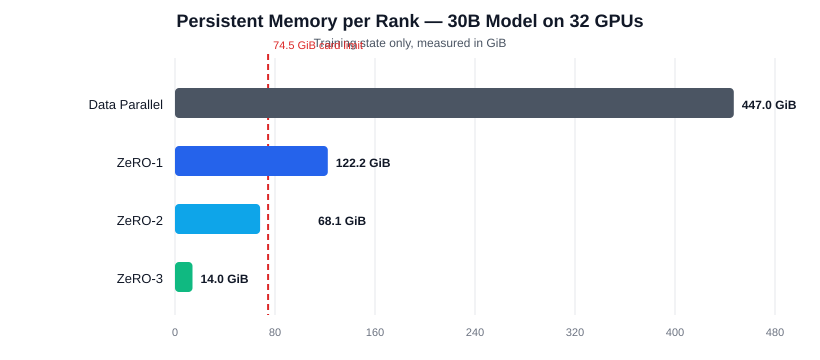

In [11]:
# MEMORY_BAR_CHART
memory_chart_labels = STRATEGIES
memory_chart_values = [gib(MODEL_30B, bytes_per_parameter(strategy, 32)) for strategy in STRATEGIES]


def build_memory_bar_svg(labels, values, card_limit=74.5):
    width, height = 820, 360
    left, right, top = 175, 775, 58
    chart_width = right - left
    maximum = 480.0
    colors = ["#4B5563", "#2563EB", "#0EA5E9", "#10B981"]
    parts = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        '<text x="410" y="27" text-anchor="middle" font-family="Arial" font-size="18" font-weight="bold" fill="#111827">Persistent Memory per Rank — 30B Model on 32 GPUs</text>',
        '<text x="410" y="47" text-anchor="middle" font-family="Arial" font-size="12" fill="#4B5563">Training state only, measured in GiB</text>',
    ]
    for tick in range(0, 481, 80):
        x = left + chart_width * tick / maximum
        parts.append(f'<line x1="{x:.1f}" y1="{top}" x2="{x:.1f}" y2="{height - 45}" stroke="#E5E7EB" stroke-width="1"/>')
        parts.append(f'<text x="{x:.1f}" y="{height - 24}" text-anchor="middle" font-family="Arial" font-size="11" fill="#6B7280">{tick}</text>')
    limit_x = left + chart_width * card_limit / maximum
    parts.append(f'<line x1="{limit_x:.1f}" y1="{top - 4}" x2="{limit_x:.1f}" y2="{height - 45}" stroke="#DC2626" stroke-width="2" stroke-dasharray="6,4"/>')
    parts.append(f'<text x="{limit_x + 5:.1f}" y="{top - 9}" font-family="Arial" font-size="11" fill="#DC2626">74.5 GiB card limit</text>')
    for index, (label, value) in enumerate(zip(labels, values)):
        y = top + 30 + index * 58
        bar_width = chart_width * value / maximum
        label_x = left + bar_width + 8
        if abs(label_x - limit_x) < 45:
            label_x = limit_x + 50
        parts.append(f'<text x="{left - 12}" y="{y + 21}" text-anchor="end" font-family="Arial" font-size="13" fill="#111827">{label}</text>')
        parts.append(f'<rect x="{left}" y="{y}" width="{bar_width:.1f}" height="30" rx="4" fill="{colors[index]}"/>')
        parts.append(f'<text x="{min(label_x, right - 3):.1f}" y="{y + 21}" font-family="Arial" font-size="12" font-weight="bold" fill="#111827">{value:.1f} GiB</text>')
    parts.append('</svg>')
    return ''.join(parts)


MEMORY_CHART_SVG = build_memory_bar_svg(memory_chart_labels, memory_chart_values)
try:
    from IPython.display import SVG, display
    display(SVG(MEMORY_CHART_SVG))
except ImportError:
    print("Graphical SVG display is available in Jupyter and Colab. Text fallback:")
    scale = 48 / max(memory_chart_values)
    for label, value in zip(memory_chart_labels, memory_chart_values):
        print(f"{label:<15} {'#' * max(1, round(value * scale))} {value:.1f} GiB")

## 8. Computation and communication changes

The neural-network forward/backward arithmetic per rank remains approximately the same because every rank still processes its microbatch through all three layers. The optimizer work changes sharply: data parallelism updates all 2,048 parameters on every rank, whereas each ZeRO rank updates only 64.

ZeRO-3 does not reduce model FLOPs. Its extra work is layer materialization and orchestration, and its extra cost is parameter communication.

In [12]:
ring_factor = (WORLD_SIZE - 1) / WORLD_SIZE
approximate_model_work = 3 * SAMPLES_PER_RANK * PARAM_COUNT

print(f"{'Strategy':<15} {'Model work/rank':>17} {'Optimizer/rank':>16} {'Optimizer global':>18} {'Collectives per step':>30}")
print('-' * 103)
for strategy in STRATEGIES:
    optimizer_per_rank = PARAM_COUNT if strategy == "Data Parallel" else SHARD_SIZE
    optimizer_global = optimizer_per_rank * WORLD_SIZE
    if strategy == "Data Parallel":
        collectives = "gradient all-reduce"
    elif strategy in ("ZeRO-1", "ZeRO-2"):
        collectives = "reduce-scatter + all-gather"
    else:
        collectives = "6 layer gathers + reduce-scatter"
    print(
        f"{strategy:<15} {approximate_model_work:>17,} {optimizer_per_rank:>16,} "
        f"{optimizer_global:>18,} {collectives:>30}"
    )

print()
print(f"Exact 32-rank DP/ZeRO-1/ZeRO-2 communication: {2 * ring_factor:.4f}P per step (about 2P)")
print(f"Exact 32-rank ZeRO-3 communication:            {3 * ring_factor:.4f}P per step (about 3P)")
print("For ZeRO-3, the six layer gathers sum to 2P: one full model across forward and one across backward.")
print("For the 30B example, P = 60 GB, so the lesson approximation is 120 GB versus 180 GB per rank per step.")

Strategy          Model work/rank   Optimizer/rank   Optimizer global           Collectives per step
-------------------------------------------------------------------------------------------------------
Data Parallel              49,152            2,048             65,536            gradient all-reduce
ZeRO-1                     49,152               64              2,048    reduce-scatter + all-gather
ZeRO-2                     49,152               64              2,048    reduce-scatter + all-gather
ZeRO-3                     49,152               64              2,048 6 layer gathers + reduce-scatter

Exact 32-rank DP/ZeRO-1/ZeRO-2 communication: 1.9375P per step (about 2P)
Exact 32-rank ZeRO-3 communication:            2.9062P per step (about 3P)
For ZeRO-3, the six layer gathers sum to 2P: one full model across forward and one across backward.
For the 30B example, P = 60 GB, so the lesson approximation is 120 GB versus 180 GB per rank per step.


## 9. What I understood from the experiment

My main takeaway is that ZeRO changes **who owns training state**, not the learning algorithm. All four strategies processed the same microbatches through the same three-layer network and produced equivalent FP32 master parameters and Adam moments after four updates.

With ordinary data parallelism, every rank permanently stores all three layers, all gradients, and all optimizer state. ZeRO-1 still keeps all three FP16 layers and a full gradient buffer, but it divides the FP32 master parameters and Adam moments. ZeRO-2 also retains only owned gradient pieces. ZeRO-3 goes further: each rank permanently stores only a small piece of every layer, so the current layer must be gathered before its forward or backward computation and released afterward.

The first large saving comes from ZeRO-1 because the FP32 master parameters and two Adam moments account for 12 of the 16 bytes stored per parameter. ZeRO-1 and ZeRO-2 remain near the lesson's `2P` communication because they use gradient reduce-scatter followed by updated-parameter all-gather. ZeRO-3 reaches roughly `3P` because the layer parameters are gathered once across the forward pass and once across the backward pass, in addition to gradient reduce-scatter.

For the 30B example on 80 GB cards, data parallelism and ZeRO-1 do not fit even before activations. ZeRO-2 first fits at 32 GPUs in the table, while ZeRO-3 fits from 8. I would prefer ZeRO-2 when enough GPUs and activation headroom are available, and use ZeRO-3 when model-state memory is the binding constraint.

CPU timing is not evidence that one stage is faster on GPUs. A production decision must measure the real model, largest gathered layer, activations, temporary buffers, interconnect topology, bucket sizes, and communication overlap.

### My submission check

I can explain which arrays each rank owns, how the three layers move during ZeRO-3, why all stages produce the same update, and why lower persistent memory can require more communication.